In [2]:
# this for CNN
# will use torch.nn.Conv2d and torchvision
import torch
from torch import nn

import torchvision
from torchvision import transforms
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
print(torch.__version__)
print(torchvision.__version__)

2.6.0+cu124
0.21.0+cu124


In [3]:
# getting a dataset(fashion mnist)

train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)


100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.49MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.2MB/s]


In [4]:
len(train_data)


60000

In [5]:
image, label = train_data[0]
label

9

In [6]:
len(image)

1

In [7]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
len(train_data.classes)

10

In [9]:
train_data.class_to_idx# to see all the class and their indexes

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [10]:
train_data.targets# gives the target tensor array

tensor([9, 0, 0,  ..., 3, 0, 5])

In [11]:
# visualising the data
print(f"image-shape{image.shape}")

image-shapetorch.Size([1, 28, 28])


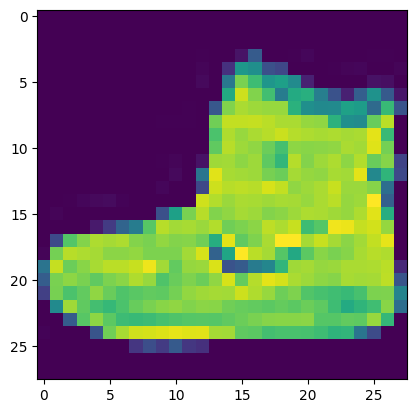

In [12]:
plt.imshow(image.squeeze()) # if its b&w then why is there green channels here plt.imshow is for image nice.
plt.show()

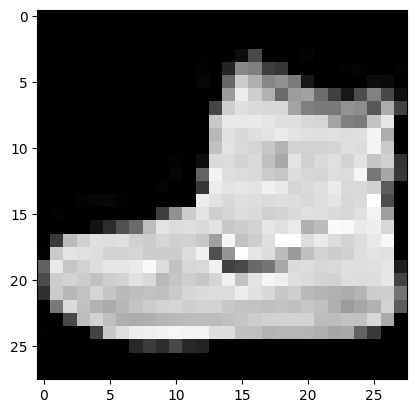

In [13]:
plt.imshow(image.squeeze(), cmap="gray")
plt.show()

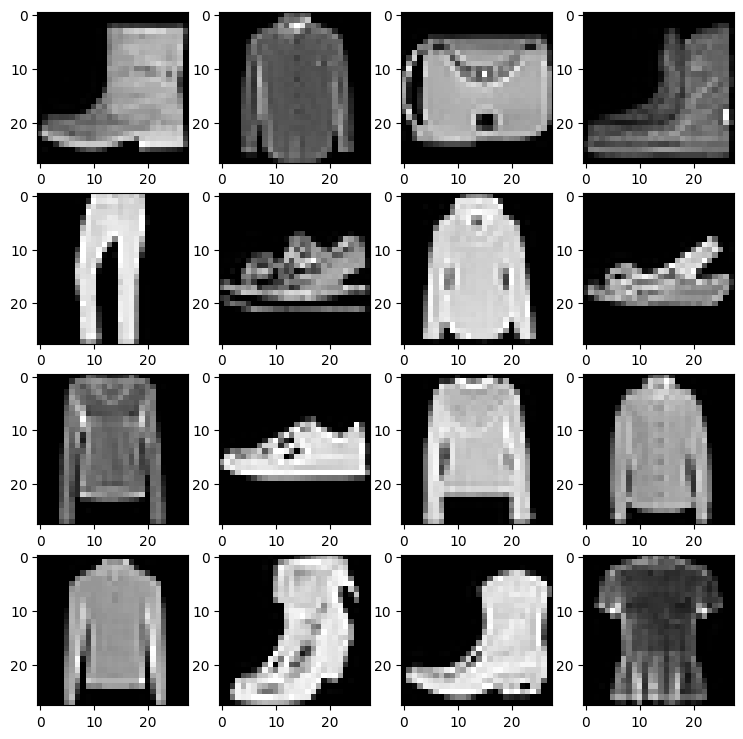

In [14]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [15]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True
)
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False
)

In [16]:
print(f"Dataloader:{train_dataloader}\n")
print(f"Length of train dataloader:{len(train_dataloader)}\n")
print(f"Type of train dataloader:{type(train_dataloader)}\n")
print(f"Length of test dataloader:{len(test_dataloader)}\n")
print(f"Type of test dataloader:{type(test_dataloader)}\n")

Dataloader:<torch.utils.data.dataloader.DataLoader object at 0x79f0361c5b90>

Length of train dataloader:1875

Type of train dataloader:<class 'torch.utils.data.dataloader.DataLoader'>

Length of test dataloader:313

Type of test dataloader:<class 'torch.utils.data.dataloader.DataLoader'>



In [17]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

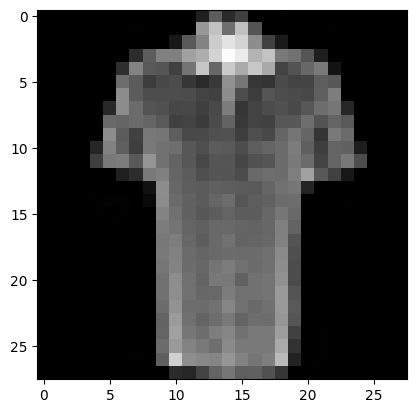

Label: Shirt


In [18]:
# sample
torch.manual_seed(42)# for reproducibility
random_idx = torch.randint(0,len(train_features_batch), size=[1]).item()# generating a random_idx of size 1 between 0 and total length of batch
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.show()
print(f"Label: {train_data.classes[label]}")

In [19]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape: int,hidden_units: int, output_shape: int):
     super().__init__()
     self.layer_stack = nn.Sequential(
         nn.Flatten(),
         nn.Linear(in_features=input_shape, out_features=hidden_units),
         nn.Linear(in_features=hidden_units, out_features=output_shape)
     )
  def forward(self, x):

    return self.layer_stack(x)



In [20]:
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(
    input_shape=784,
    hidden_units=10,
    output_shape=len(train_data.classes)
)
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [19]:
import requests
from pathlib import Path

if Path('helper_functions.py').is_file():
    print('helper_functions.py already exists, skipping download')
else:
    print('Downloading helper_functions.py')
    request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
    with open('helper_functions.py', 'wb') as f:
        f.write(request.content)

In [20]:
from helper_functions import accuracy_fn



In [21]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.001)

NameError: name 'model_0' is not defined

In [28]:
from timeit import default_timer as Timer# this is to keep track of how much time our neural network is taking
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [31]:
from functools import total_ordering
# now lets train it
from tqdm.auto import tqdm# for visualisation of speed of training just looks cool
torch.manual_seed(42)
train_time_start_on_cpu = Timer()# starting timer
for epoch in tqdm(range(10)):
    print(f"Epoch: {epoch}\n---------")
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):# batch is number of batches, then in one batch ew have X images with target y
        model_0.train()
        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        if batch%400 ==0:
          print(loss)
        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
    train_loss /= len(train_dataloader)
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_0(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    print(f"\nTrain loss: {train_loss} | Test loss: {test_loss}, Test acc: {test_acc}%\n")
train_time_end_on_cpu = Timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device="cpu")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
tensor(0.4667, grad_fn=<NllLossBackward0>)
Looked at 0/60000 samples
tensor(0.5463, grad_fn=<NllLossBackward0>)
Looked at 12800/60000 samples
tensor(0.6696, grad_fn=<NllLossBackward0>)
Looked at 25600/60000 samples
tensor(0.4233, grad_fn=<NllLossBackward0>)
Looked at 38400/60000 samples
tensor(0.5191, grad_fn=<NllLossBackward0>)
Looked at 51200/60000 samples

Train loss: 0.5949441194534302 | Test loss: 0.6111149787902832, Test acc: 79.00359424920129%

Epoch: 1
---------
tensor(0.5343, grad_fn=<NllLossBackward0>)
Looked at 0/60000 samples
tensor(0.5977, grad_fn=<NllLossBackward0>)
Looked at 12800/60000 samples
tensor(0.5834, grad_fn=<NllLossBackward0>)
Looked at 25600/60000 samples
tensor(0.6914, grad_fn=<NllLossBackward0>)
Looked at 38400/60000 samples
tensor(0.4262, grad_fn=<NllLossBackward0>)
Looked at 51200/60000 samples

Train loss: 0.5810732245445251 | Test loss: 0.5981602668762207, Test acc: 79.51277955271566%

Epoch: 2
---------
tensor(0.3748, grad_fn=<NllLoss

In [26]:
print(y.shape, y.dtype)
print(y.min(), y.max())


torch.Size([16]) torch.int64
tensor(1) tensor(9)


In [27]:
print(y_pred.shape)


torch.Size([32, 10])


In [22]:
# making prediction
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn):
  loss,acc=0,0
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      y_pred = model(X)
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
    loss /= len(data_loader)
    acc /= len(data_loader)
  print(f"loss{loss}, acc{acc}")
# eval_model(model_0, test_dataloader, loss_fn, accuracy_fn)


In [29]:
# now lets improve the accuracy and overall model performance
!nvidia-smi

Sat Jul 19 15:33:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:
if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"
device

'cuda'

In [24]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape: int,hidden_units: int, output_shape: int):
     super().__init__()
     self.layer_stack = nn.Sequential(
         nn.Flatten(),
         nn.Linear(in_features=input_shape, out_features=hidden_units),
         nn.ReLU(),
         nn.Linear(in_features=hidden_units, out_features=hidden_units),
         nn.ReLU(),
         nn.Linear(in_features=hidden_units, out_features=output_shape)
     )
  def forward(self, x):

    return self.layer_stack(x)


In [25]:
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(
    input_shape=784,
    hidden_units=10,
    output_shape=len(train_data.classes)
).to(device)
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
    (5): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [26]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [28]:
from functools import total_ordering
# now lets train it
from tqdm.auto import tqdm # for visualisation of speed of training just looks cool
torch.manual_seed(42)
train_time_start_on_cpu = Timer() # starting timer
for epoch in tqdm(range(10)):
    print(f"Epoch: {epoch}\n---------")
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):# batch is number of batches, then in one batch ew have X images with target y
        model_0.train()
        y_pred = model_0(X.to(device))
        loss = loss_fn(y_pred.to(device), y.to(device))

        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
    train_loss /= len(train_dataloader)
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_0(X.to(device))
            test_loss += loss_fn(test_pred.to(device), y.to(device))
            test_acc += accuracy_fn(y_true=y.to(device), y_pred=test_pred.argmax(dim=1))
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    print(f"\nTrain loss: {train_loss} | Test loss: {test_loss}, Test acc: {test_acc}%\n")
train_time_end_on_cpu = Timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device="cpu")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45178455114364624 | Test loss: 0.48083290457725525, Test acc: 82.60782747603834%

Epoch: 1
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.44305649399757385 | Test loss: 0.4661470353603363, Test acc: 83.19688498402556%

Epoch: 2
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.4331234097480774 | Test loss: 0.46241340041160583, Test acc: 83.73602236421725%

Epoch: 3
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.42481550574302673 | Test loss: 0.458

In [31]:
# making prediction
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn):
  loss,acc=0,0
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      y_pred = model(X.to(device))
      loss += loss_fn(y_pred, y.to(device))
      acc += accuracy_fn(y_true=y.to(device), y_pred=y_pred.argmax(dim=1))
    loss /= len(data_loader)
    acc /= len(data_loader)
  print(f"loss{loss}, acc{acc}")
eval_model(model_0, test_dataloader, loss_fn, accuracy_fn)

loss0.43764975666999817, acc84.42492012779553


In [29]:
# we got an better accuracy by introducing some non-linearity in model, we can functalise this also, but as we can see it not much different,
# so now we will do the same thing using convulational neural network, so we used linear, then non-linear, then also accuracy is not much , so conv is last hope🥹🥹


In [22]:
import torch
from torch import nn
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1,stride=1),#2-d for 2-d layer
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1,stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)

    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1,stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1,stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)

    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )
  def forward(self, x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x

In [21]:
image.shape

torch.Size([1, 28, 28])

In [25]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(train_data.classes)).to(device)


In [1]:
import torch
from torch import nn

In [32]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [37]:
def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, device: torch.device):
  train_loss = 0
  train_acc=0
  for batch, (X, y) in enumerate(train_dataloader):# batch is number of batches, then in one batch ew have X images with target y
      model.train()
      X,y = X.to(device), y.to(device)
      y_pred = model(X.to(device))
      loss = loss_fn(y_pred.to(device), y.to(device))

      train_loss += loss
      train_acc += accuracy_fn(y_true=y.to(device), y_pred=y_pred.argmax(dim=1))
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if batch % 400 == 0:
          print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)
  print(f"Train loss: {train_loss} | Train acc: {train_acc}%\n")


In [42]:
def test_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device: torch.device):
  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():

    for X, y in test_dataloader:
        X,y = X.to(device), y.to(device)
        test_pred = model(X.to(device))
        test_loss += loss_fn(test_pred.to(device), y.to(device))
        test_acc += accuracy_fn(y_true=y.to(device), y_pred=test_pred.argmax(dim=1))
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
    print(f" Test loss: {test_loss}, Test acc: {test_acc}%\n")


In [43]:
# training our odel
from tqdm.auto import tqdm
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from timeit import default_timer as Timer# this is to keep track of how much time our neural network is taking
train_time_start_model_2 = Timer()# starting timer
for epoch in tqdm(range(10)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_2, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, device=device)
    test_step(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)
train_time_end_model_2 = Timer()


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.4558925926685333 | Train acc: 83.50166666666667%

 Test loss: 0.438602089881897, Test acc: 84.41493610223642%

Epoch: 1
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.4135400950908661 | Train acc: 85.09666666666666%

 Test loss: 0.4140162765979767, Test acc: 85.14376996805112%

Epoch: 2
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.3864324688911438 | Train acc: 86.06333333333333%

 Test loss: 0.39099833369255066, Test acc: 86.11222044728434%

Epoch: 3
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 

In [44]:
#best result so far
# using this model, and including some dataprocessing steps in starting we can make our model, useful for practical datasets
# here i am not doing that, and this is the end of the sos_25 for this side.